In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [3]:
# Load Dataset
hospital_ml_df = pd.read_csv(r"E:\MCA SEM-III\CAUE_603_DATA_ANALYTICS\CASE_STUDY\Hospital-Data-Analysis\data\cleaned\hospital_cleaned.csv")

In [4]:
# Display First 5 Records
hospital_ml_df.head()

,Patient_ID,Admit_Date,Discharge_Date,Diagnosis,Bed_Occupancy,Test,Doctor,Followup Date,Feedback,Billing Amount,Health Insurance Amount,Stay_Days,Admit_Year
0,28377,2022-01-20,2022-01-23,Viral Infection,General,CT Scan,Jaya Yadav,2022-02-14,3.5,3323.0,3323.0,3,2022
1,35552,2025-02-08,2025-02-13,Pneumonia,Semi-Private,Blood Test,Neha Patel,2025-03-01,4.0,4445.0,2687.6,5,2025
2,20677,2023-06-12,2023-06-17,Malaria,Emergency,Urine Test,Karan Joshi,2023-07-07,4.0,1816.0,1219.7,5,2023
3,39475,2025-06-20,2025-06-25,Asthma,General,Blood Test,Arjun Rao,2025-07-22,4.5,1481.0,1359.9,5,2025
4,22238,2024-05-03,2024-06-03,Heart Disease,Emergency,Blood Test,Neha Patel,2024-06-19,5.0,4901.0,4270.6,31,2024


In [5]:
# Display Size Of Dataset
print("Dataset Shape: ", hospital_ml_df.shape)

Dataset Shape:  (9457, 13)


In [6]:
# Display Columns Name Of Dataset
hospital_ml_df.columns.to_list()

['Patient_ID',
 'Admit_Date',
 'Discharge_Date',
 'Diagnosis',
 'Bed_Occupancy',
 'Test',
 'Doctor',
 'Followup Date',
 'Feedback',
 'Billing Amount',
 'Health Insurance Amount',
 'Stay_Days',
 'Admit_Year']

In [7]:
# Display Information Of Dataset
hospital_ml_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9457 entries, 0 to 9456
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient_ID               9457 non-null   int64  
 1   Admit_Date               9457 non-null   object 
 2   Discharge_Date           9457 non-null   object 
 3   Diagnosis                9457 non-null   object 
 4   Bed_Occupancy            9457 non-null   object 
 5   Test                     9457 non-null   object 
 6   Doctor                   9457 non-null   object 
 7   Followup Date            9457 non-null   object 
 8   Feedback                 9457 non-null   float64
 9   Billing Amount           9457 non-null   float64
 10  Health Insurance Amount  9457 non-null   float64
 11  Stay_Days                9457 non-null   int64  
 12  Admit_Year               9457 non-null   int64  
dtypes: float64(3), int64(3), object(7)
memory usage: 960.6+ KB


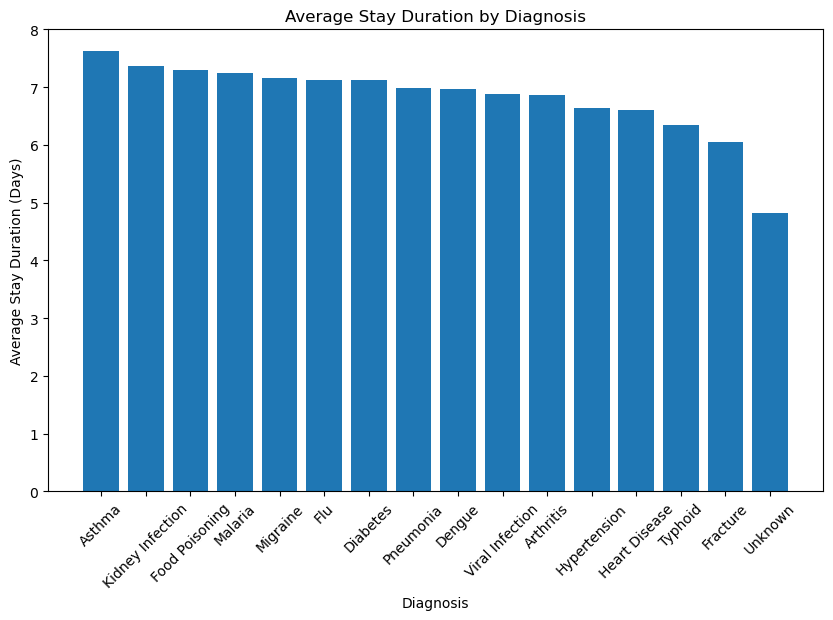

In [8]:
# Diagnosis vs Stay Duration
diagnosis_stay = (hospital_ml_df.groupby("Diagnosis")["Stay_Days"].mean().sort_values(ascending=False))
plt.figure(figsize=(10, 6))
plt.bar(diagnosis_stay.index, diagnosis_stay.values)
plt.title("Average Stay Duration by Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Average Stay Duration (Days)")
plt.xticks(rotation=45)
plt.show()

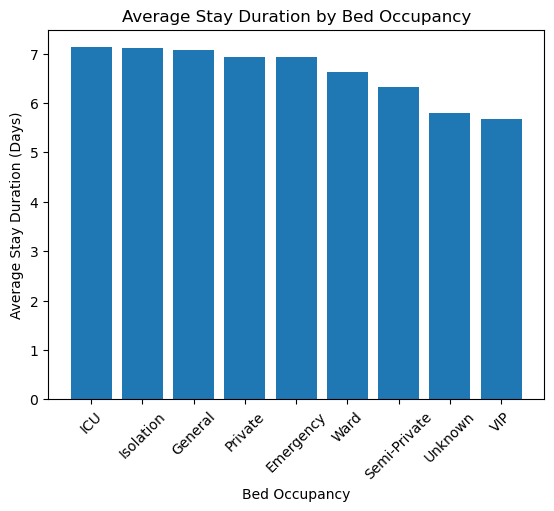

In [9]:
# Bed Occupancy vs Stay Duration
bed_stay = (hospital_ml_df.groupby("Bed_Occupancy")["Stay_Days"].mean().sort_values(ascending=False))
plt.bar(bed_stay.index, bed_stay.values)
plt.title("Average Stay Duration by Bed Occupancy")
plt.xlabel("Bed Occupancy")
plt.ylabel("Average Stay Duration (Days)")
plt.xticks(rotation=45)
plt.show()

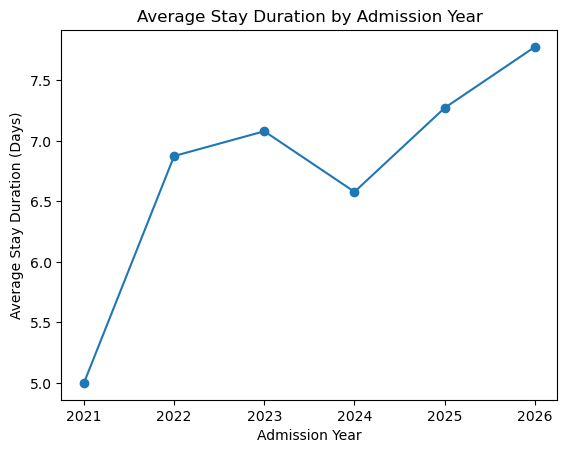

In [10]:
# Admission Year vs Stay Duration
year_stay = (hospital_ml_df.groupby("Admit_Year")["Stay_Days"].mean().sort_index())
plt.plot(year_stay.index, year_stay.values, marker="o")
plt.title("Average Stay Duration by Admission Year")
plt.xlabel("Admission Year")
plt.ylabel("Average Stay Duration (Days)")
plt.show()

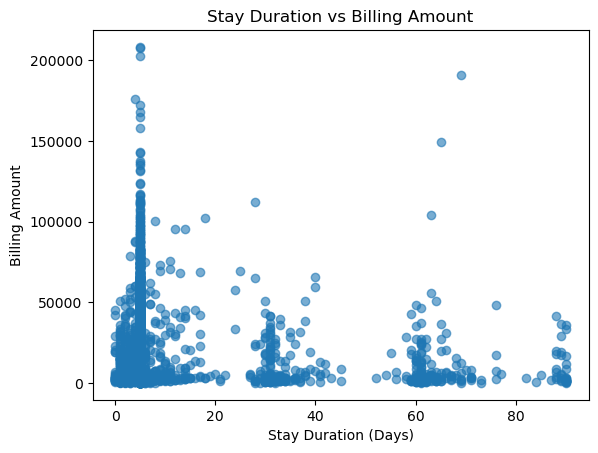

In [11]:
# Stay Duration vs Billing Amount
plt.scatter(hospital_ml_df["Stay_Days"], hospital_ml_df["Billing Amount"], alpha=0.6)
plt.title("Stay Duration vs Billing Amount")
plt.xlabel("Stay Duration (Days)")
plt.ylabel("Billing Amount")
plt.show()

In [12]:
# Select input features
X = hospital_ml_df[
    [
        "Diagnosis",
        "Bed_Occupancy",
        "Test",
        "Doctor",
        "Admit_Year"
    ]
]

# Select target
y = hospital_ml_df["Stay_Days"]

In [13]:
# Convert categorical columns into numerical columns
X = pd.get_dummies(X, dtype=int)

# Remove records where the target is missing
valid = y.notna()

X = X.loc[valid]
y = y.loc[valid]

In [14]:
# Split Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (7565, 54)
Testing Data: (1892, 54)


In [15]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [16]:
# Display intercept
print("Intercept:", model.intercept_)

# Display coefficients
coefficients = pd.DataFrame(
    {
        "Feature": X.columns,
        "Coefficient": model.coef_
    }
)
print(coefficients)

Intercept: -305.31178751029665
                       Feature  Coefficient
0                   Admit_Year     0.154125
1          Diagnosis_Arthritis     0.140505
2             Diagnosis_Asthma     0.425929
3             Diagnosis_Dengue     0.238155
4           Diagnosis_Diabetes     0.292232
5                Diagnosis_Flu     0.458895
6     Diagnosis_Food Poisoning     0.168619
7           Diagnosis_Fracture    -1.067840
8      Diagnosis_Heart Disease     0.279480
9       Diagnosis_Hypertension     0.141414
10  Diagnosis_Kidney Infection     0.298494
11           Diagnosis_Malaria     0.536133
12          Diagnosis_Migraine    -0.080086
13         Diagnosis_Pneumonia     0.109775
14           Diagnosis_Typhoid    -0.239880
15           Diagnosis_Unknown    -1.927691
16   Diagnosis_Viral Infection     0.225866
17     Bed_Occupancy_Emergency     0.133120
18       Bed_Occupancy_General     0.146887
19           Bed_Occupancy_ICU     0.628710
20     Bed_Occupancy_Isolation     0.533105
2

In [17]:
# Make predictions
y_pred = model.predict(X_test)

# Display actual and predicted values
result = pd.DataFrame(
    {
        "Actual": y_test,
        "Predicted": y_pred
    }
)
print(result.head(10))

      Actual  Predicted
3836       5   6.772548
8166       5   6.200159
5577       5   6.811847
7701       5   7.050715
5991       5   7.165678
2167       5   5.992951
8834       5   6.737579
5226       5   7.119891
4899       5   6.710983
131        5   7.426037


In [18]:
# Evaluate the model using MAE, MSE, RMSE and R²
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

rmse = np.sqrt(mse)
print("RMSE:", rmse)

r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

MAE: 3.884282084322079
MSE: 100.59600150626909
RMSE: 10.02975580491714
R2 Score: -0.0016429205990287077


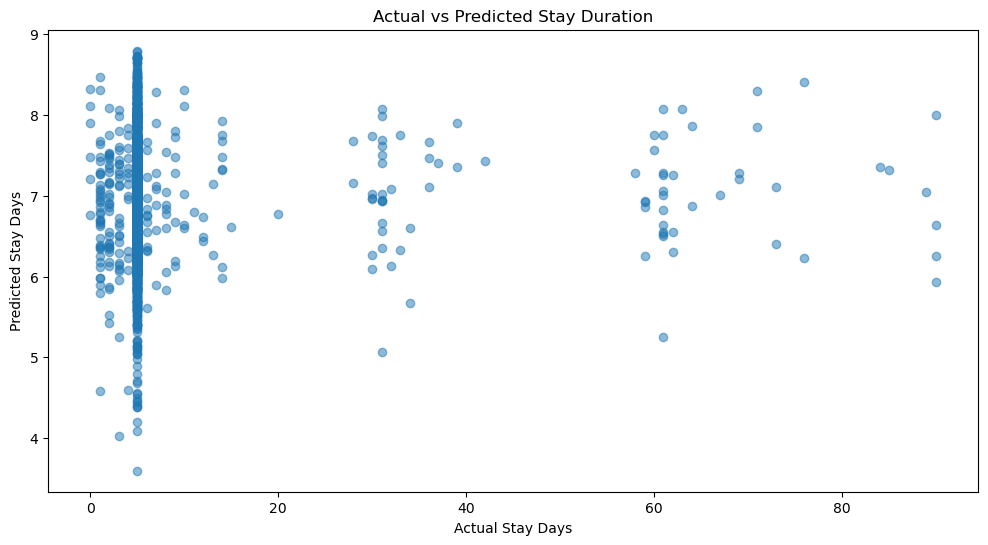

In [19]:
# Actual vs Predicted Stay Duration
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Stay Days")
plt.ylabel("Predicted Stay Days")
plt.title("Actual vs Predicted Stay Duration")
plt.show()

In [20]:
# Experiment 1: Change the test size
for size in [0.2, 0.3, 0.4]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=size, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\nTest Size:", size)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))


Test Size: 0.2
MAE: 3.884282084322079
R2 Score: -0.0016429205990287077

Test Size: 0.3
MAE: 3.8244366099426856
R2 Score: -0.004011379004240867

Test Size: 0.4
MAE: 3.9482764449918184
R2 Score: -0.003510969349426629


In [21]:
# Experiment 2: Change the random state
for state in [10, 20, 42]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=state)
    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print("\nRandom State:", state)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))


Random State: 10
MAE: 4.169081810059888
R2 Score: -0.004039246546352793

Random State: 20
MAE: 3.9913119383649396
R2 Score: -0.004994677948014115

Random State: 42
MAE: 3.884282084322079
R2 Score: -0.0016429205990287077


In [22]:
# Experiment 3: Use fewer features
# Select fewer features
X_simple = hospital_ml_df[["Diagnosis", "Admit_Year"]]
y_simple = hospital_ml_df["Stay_Days"]

# Convert categorical values
X_simple = pd.get_dummies(X_simple, dtype=int)

# Keep rows with a valid target
valid = y_simple.notna()
X_simple = X_simple.loc[valid]
y_simple = y_simple.loc[valid]

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_simple, y_simple, test_size=0.2, random_state=42)

# Train model
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)

# Predict
y_pred = simple_model.predict(X_test)

# Evaluate
print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 3.8892091511915248
R2 Score: -2.3429645794603715e-06


In [23]:
# Create the model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [24]:
# Make predictions
rf_pred = rf_model.predict(X_test)

In [25]:
# Evaluate the model using MAE, MSE, RMSE and R²
print("MAE:", mean_absolute_error(y_test, rf_pred))
print("MSE:", mean_squared_error(y_test, rf_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))
print("R2 Score:", r2_score(y_test, rf_pred))

MAE: 3.9514068944011855
MSE: 102.09118493166577
RMSE: 10.104018256696975
R2 Score: -0.016530588802742052


In [26]:
# Compare both models
comparison = pd.DataFrame(
    {
        "Model": ["Linear Regression", "Random Forest"],
        "MAE": [mean_absolute_error(y_test, y_pred), mean_absolute_error(y_test, rf_pred)],
        "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred)), np.sqrt(mean_squared_error(y_test, rf_pred))],
        "R2 Score": [r2_score(y_test, y_pred), r2_score(y_test, rf_pred)]
    }
)
print(comparison)

               Model       MAE       RMSE  R2 Score
0  Linear Regression  3.889209  10.021539 -0.000002
1      Random Forest  3.951407  10.104018 -0.016531
